# Facial Emotions Recognition System

##  Importing the Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O 
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.metrics import accuracy_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix


## Loading the Dataset

In [5]:
# Path to the directory
data= pd.read_csv('D:\\Minor2_FERSystem\\Dataset\\fer2013.csv')

## Dataset Overview

In [6]:
data.shape

(35887, 3)

In [7]:
data.isnull().sum()

emotion    0
pixels     0
Usage      0
dtype: int64

In [8]:
# first 5 row of data
data.head(5)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [9]:
#check usage values
#80% training, 10% validation and 10% test
data.Usage.value_counts()

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

In [11]:
#check target labels
emotion_map= {0:'Angry', 1:'Digust',2: 'Fear', 3:'Happy', 4:'Sad', 5:'Surprise', 6:'Neutral'}
emotion_counts = data['emotion'].value_counts(sort=False).reset_index()
emotion_counts.columns =['emotion', 'number']
emotion_counts['emotion']= emotion_counts['emotion'].map(emotion_map)
emotion_counts

,emotion,number
0,Angry,4953
1,Fear,5121
2,Sad,6077
3,Neutral,6198
4,Happy,8989
5,Surprise,4002
6,Digust,547


## Data Analysis (Graphical Representation)

###  BarGraph

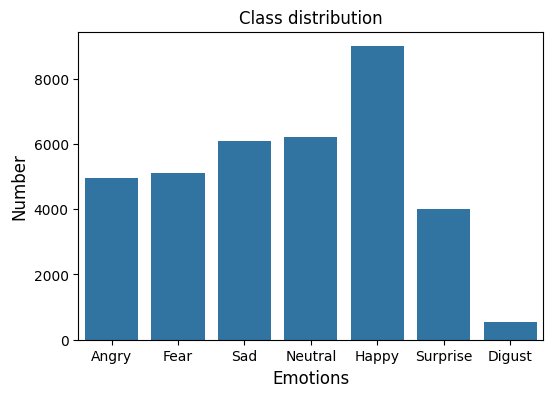

In [13]:
# Plotting a bar graph
plt.figure(figsize=(6,4))
sns.barplot(x=emotion_counts.emotion, y=emotion_counts.number)
plt.title('Class distribution')
plt.ylabel('Number', fontsize=12)
plt.xlabel('Emotions', fontsize=12)
plt.show()

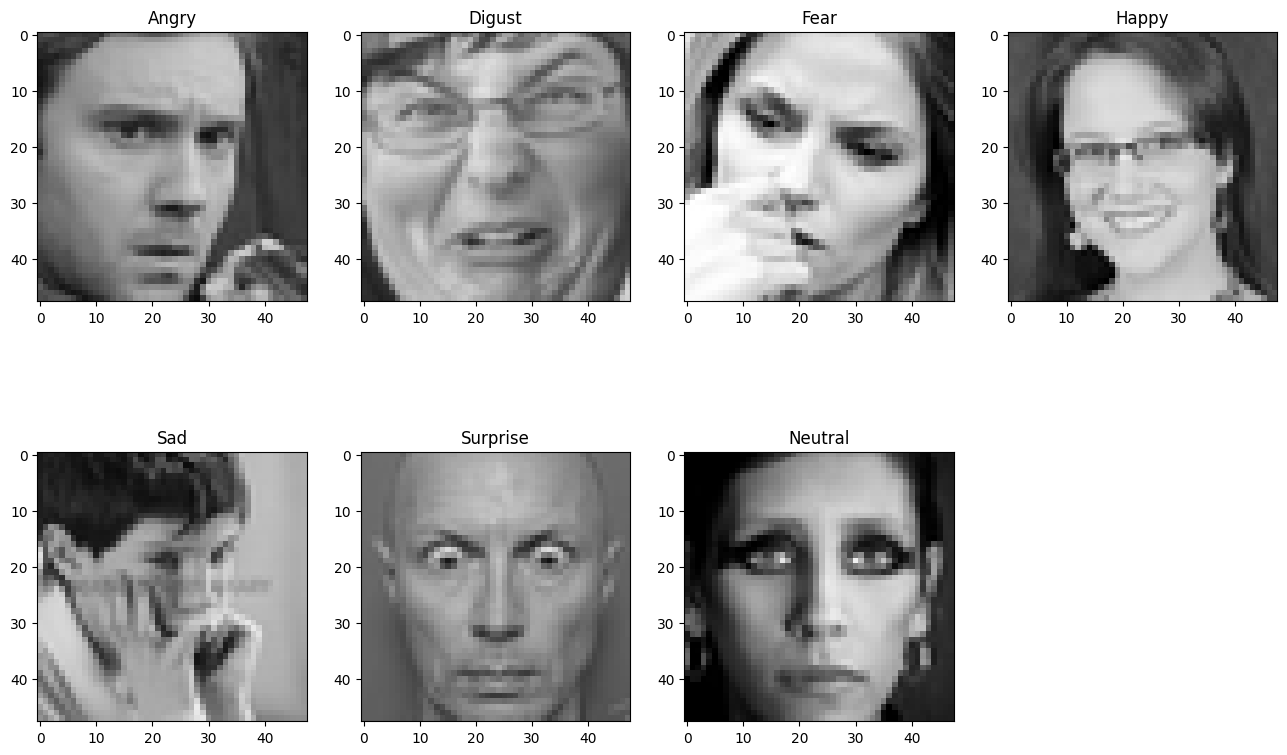

In [14]:
def row2image(row):
    pixels, emotion = row['pixels'], emotion_map[row['emotion']]
    img= np.array(pixels.split(), dtype='float32')
    img= img.reshape(48,48)
    image =np.zeros((48,48,3))
    image[:,:,0]= img
    image[:,:,1]= img
    image[:,:,2]= img
    return image.astype(np.uint8), emotion

plt.figure(0, figsize=(16,10))
for i in range(1,8):
    face = data[data['emotion']==i-1].iloc[0]
    img, label =row2image(face)
    plt.subplot(2,4,i)
    plt.imshow(img)
    plt.title(label)

plt.show()

## Pre-processing data

### Shuffling the data

In [15]:
data= data.sample(frac=1)

### One Hot Encoding

In [16]:
labels= to_categorical(data[['emotion']],num_classes=7)

In [17]:
#Changing image pixels to Numpy array
train_pixels = data["pixels"].astype(str).str.split(" ").tolist()
train_pixels = np.uint8(train_pixels)

###  Standardization

In [18]:
# StandartScaler() function takes only 2 dimensional array as i/p,
# we reshape the data then apply our scaler to make the mean zero and standart deviation as unit.
pixels = train_pixels.reshape((35887*2304,1))

In [19]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
pixels =scaler.fit_transform(pixels)

### Reshaping the data (48,48)

In [20]:
pixels= train_pixels.reshape((35887, 48, 48,1))

### Train test validation split

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(pixels, labels, test_size=0.1, shuffle=False)
X_train, X_val, y_train, y_val= train_test_split(X_train, y_train, test_size=0.1, shuffle=False)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(29068, 48, 48, 1)
(3589, 48, 48, 1)
(3230, 48, 48, 1)


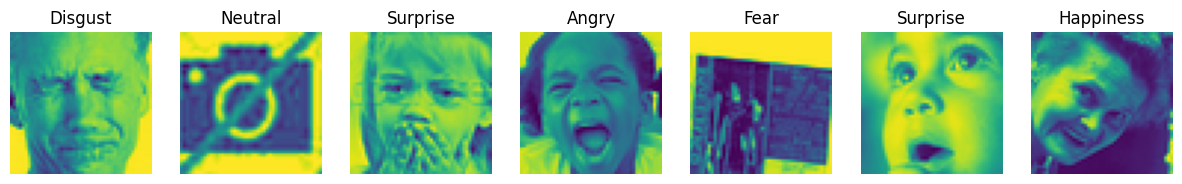

In [24]:
# train data contains one sample of each class.
plt.figure(figsize=(15,23))
label_dict= {0:'Angry', 1:'Disgust', 2:'Fear', 3 :'Happiness', 4: 'Sad', 5: 'Surprise', 6:'Neutral'}
i= 1
for i in range (7):
    img=np.squeeze(X_train[i])
    plt.subplot(1,7,i+1)
    plt.imshow(img)
    index= np.argmax(y_train[i])
    plt.title(label_dict[index])
    plt.axis('off')
    i+= 1
plt.show()

## Data augmentation using ImageDataGenerator

In [25]:
datagen= ImageDataGenerator(width_shift_range= 0.1,
                               height_shift_range=0.1,
                               horizontal_flip=True,
                               zoom_range=0.2)
valgen= ImageDataGenerator(width_shift_range= 0.1,
                               height_shift_range =0.1,
                               horizontal_flip=True,
                               zoom_range=0.2)

In [26]:
datagen.fit(X_train)
valgen.fit(X_val)

In [27]:
train_generator= datagen.flow(X_train, y_train, batch_size=64)
val_generator= datagen.flow(X_val, y_val, batch_size=64)

## Building CNN Model

### Designing a model

In [32]:
def cnn_model():

  model= tf.keras.models.Sequential()
  model.add(Input(shape=(48,48,1)))

  model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
  model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(128,(3,3), padding='same', activation='relu'))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(256,(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Flatten())
  model.add(Dense(256,activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.4))

  model.add(Dense(7, activation='softmax'))
  model.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
  return model

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization,MaxPooling2D,Activation,Input
from tensorflow.keras import regularizers
model= cnn_model()

In [35]:
model.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,007 (10.50 MB)

 Trainable params: 2,750,599 (10.49 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Early stopping

Adding checkpointer to implement Early Stopping to prevent overfitting.

In [37]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
checkpointer = [EarlyStopping(monitor= 'val_accuracy', verbose=1,
                              restore_best_weights=True,mode="max",patience= 5),
                ModelCheckpoint('best_model.h5',monitor="val_accuracy",verbose=1,
                                save_best_only=True,mode="max")]

In [38]:
history = model.fit(train_generator,
                    epochs=1,
                    batch_size=64,
                    verbose=1,
                    callbacks=[checkpointer],
                    validation_data=val_generator)

455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.1977 - loss: 4.2330
Epoch 1: val_accuracy improved from None to 0.31858, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 195s 413ms/step - accuracy: 0.2205 - loss: 4.0078 - val_accuracy: 0.3186 - val_loss: 3.3569
Restoring model weights from the end of the best epoch: 1.


## Visualizing Results

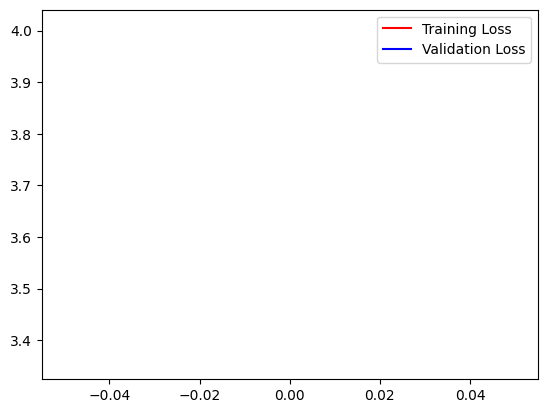

In [39]:
plt.plot(history.history["loss"],'r', label="Training Loss")
plt.plot(history.history["val_loss"],'b', label="Validation Loss")
plt.legend()

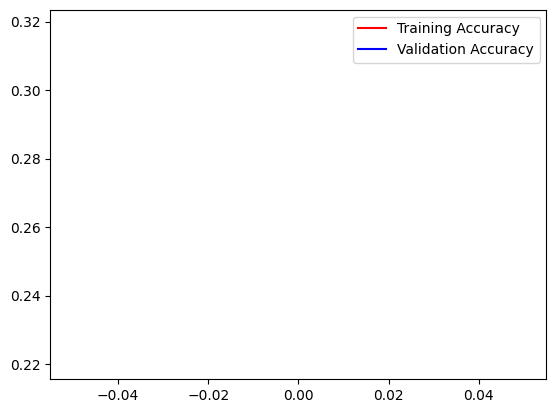

In [40]:
plt.plot(history.history["accuracy"],'r',label="Training Accuracy")
plt.plot(history.history["val_accuracy"],'b',label="Validation Accuracy")
plt.legend()

In [42]:
loss= model.evaluate(X_test,y_test)
print("Test Acc: " + str(loss[1]))

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3371 - loss: 3.3275
Test Acc: 0.3371412754058838


In [43]:
preds= model.predict(X_test)
y_pred=np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step


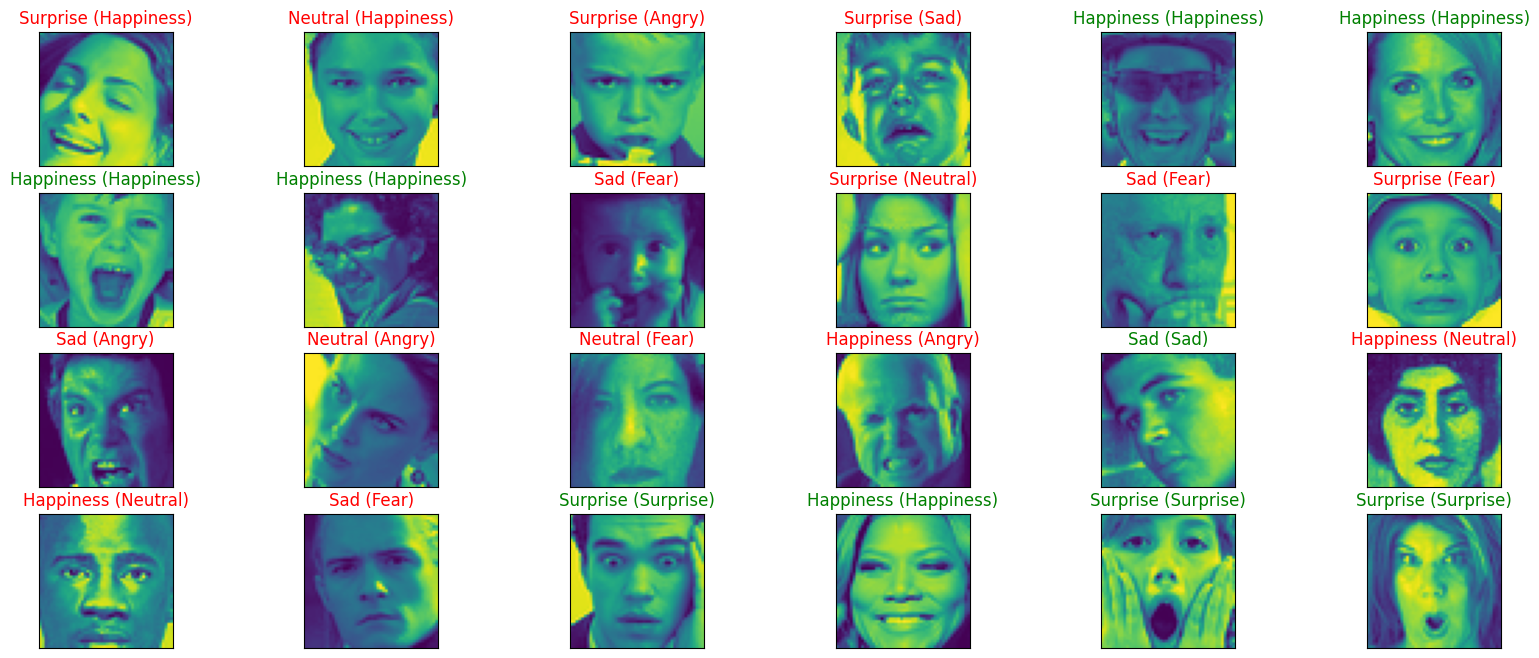

In [44]:
label_dict= {0 :'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happiness', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

figure= plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
    ax=figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[index]))
    predict_index=label_dict[(y_pred[index])]
    true_index =label_dict[np.argmax(y_test,axis=1)[index]]

    ax.set_title("{} ({})".format((predict_index),
                                  (true_index)),
                                  color=("green" if predict_index==true_index else "red"))

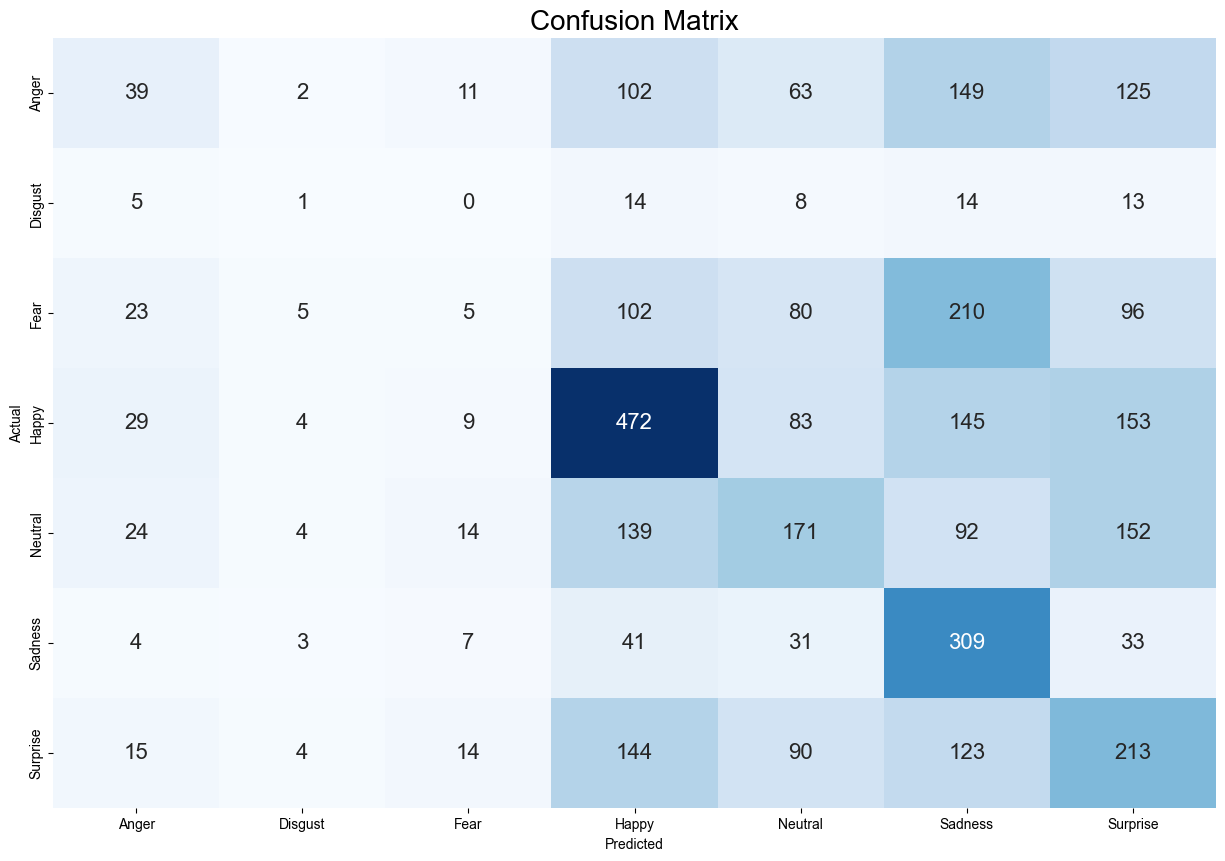

In [45]:
CLASS_LABELS= ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', "Surprise"]

cm_data= confusion_matrix(np.argmax(y_test, axis = 1 ), y_pred)
cm=pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name='Actual'
cm.columns.name='Predicted'
plt.figure(figsize=(15,10))
plt.title('Confusion Matrix',fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

In [46]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis= 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.281     0.079     0.124       491
           1      0.043     0.018     0.026        55
           2      0.083     0.010     0.017       521
           3      0.465     0.527     0.494       895
           4      0.325     0.287     0.305       596
           5      0.297     0.722     0.420       428
           6      0.271     0.353     0.307       603

    accuracy                          0.337      3589
   macro avg      0.252     0.285     0.242      3589
weighted avg      0.302     0.337     0.295      3589



## Saving the Model

In [47]:
#import pickle library
import pickle
filename='model.h5'
pickle.dump(history,open(filename,'wb'))